# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow import keras
import zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import requests
from PIL import Image
from tensorflow.keras.preprocessing import image

# Importing Dataset From Kaggle

In [ ]:
!pip install kaggle

In [ ]:
os.environ['KAGGLE_USERNAME'] = "samichohan"
os.environ['KAGGLE_KEY'] = "ca0cc6370076de058fc41b4f5761064c"

print(os.environ['KAGGLE_USERNAME'])
print(os.environ['KAGGLE_KEY'])

samichohan
ca0cc6370076de058fc41b4f5761064c


In [ ]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
cat-and-dog.zip: Skipping, found more recently modified local copy (use --force to force download)


# Unzip The Dataset

In [ ]:
zip_ref=zipfile.ZipFile('/content/cat-and-dog.zip')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

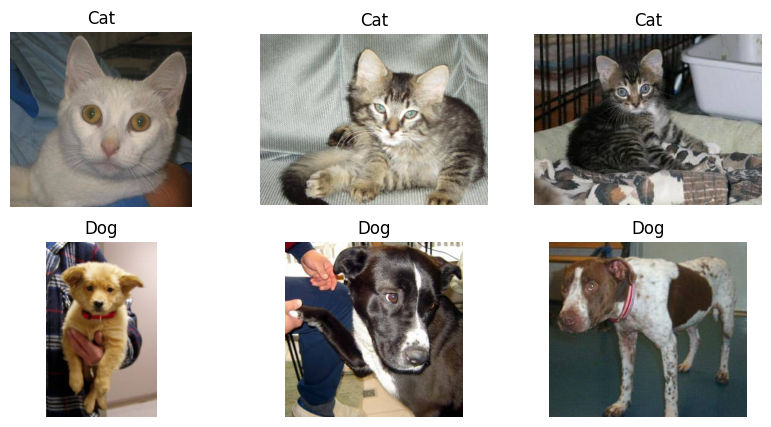

In [ ]:
# paths
cat_path = '/content/training_set/training_set/cats'
dog_path = '/content/training_set/training_set/dogs'

# random images pic karo
cat_images = random.sample(os.listdir(cat_path),3)
dog_images = random.sample(os.listdir(dog_path),3)

plt.figure(figsize=(10,5))

# cats
for i,img_name in enumerate(cat_images):
  img = Image.open(os.path.join(cat_path,img_name))
  plt.subplot(2,3,i+1)
  plt.imshow(img)
  plt.title('Cat')
  plt.axis('off')

# dogs
for i,img_name in enumerate(dog_images):
  img = Image.open(os.path.join(dog_path,img_name))
  plt.subplot(2,3,i+4)
  plt.imshow(img)
  plt.title('Dog')
  plt.axis('off')

plt.show()

In [ ]:
# checking shape of overall data
print('Training Data:')
base_path = '/content/training_set/training_set'

for folder in os.listdir(base_path):
  folder_path = os.path.join(base_path,folder)

  if os.path.isdir(folder_path):
    print(folder,":",len(os.listdir(folder_path)))

print('\nTesting Data:')
base_path = "/content/test_set/test_set"

for folder in os.listdir(base_path):
  folder_path = os.path.join(base_path,folder)

  if os.path.isdir(folder_path):
    print(folder,":",len(os.listdir(folder_path)))

Training Data:
dogs : 4006
cats : 4001

Testing Data:
dogs : 1013
cats : 1012


In [ ]:
from PIL import Image
import random

In [ ]:
# images shape
img_path = '/content/training_set/training_set/dogs'
sample_img = random.choice(os.listdir(img_path))
img = Image.open(os.path.join(img_path,sample_img))
print('Image Shape:',img.size) # (width,height)

Image Shape: (500, 374)


# Generator

A generator is like a magic tool i programming that helps us deal with big sets of data without using to much computer memory. it's like a smart assistant that only gives us the data we need. one piece at a time.instead of overwhelming us with everything at once.

# Why use Generator

Generator are cool because they save memory and work efficiently,imagine you have tons of data:generator helps process it bit by bit, making things manageable.they're like a friendly helper.giving us just the right amount ofdata when we need it. This is super handy in situations where we want to be smart about using computer resources and not waste time.





Data Augmentation: Data augmentation is a technique in machine Learning that involves applying various transfoemations to existing data to create
new.slightly modified versions.In image data.these transformation may includechanges like rotation. flipping and zooming, The goal is to increase the diversity of the trainig dataset,iproving the Model's ability to generalize to different conditions and variations in the input data.

# Preparing The Generator For Augmentation

In [ ]:
datagen=ImageDataGenerator(
    rescale=1/255 # scales the pixel values of the images in range of [0 t0 1]
  ,validation_split=0.2 # used for 20% data splitting
  ,rotation_range=10 # defines the range (in degrees) for random rotations applied to the images
  ,width_shift_range=0.1 # control the range for random horizontal shift of the images
  ,height_shift_range=0.1 # controls the range for random vertical shift of the images
  ,shear_range=0.1 # tilts the shapes of objects
  ,zoom_range=0.10 # apply zooming of the images
  ,horizontal_flip=True # enables horizontal flipping of the images
)

# Generator For Training Data & Validation Data

In [ ]:
# Training Generator
train_generator = datagen.flow_from_directory('/content/training_set/training_set',
  target_size=(150,150) #Resize The image to (150X150) pixels
  ,batch_size=128 # specifies the number of samples in each batch
  ,class_mode='binary' # specifies the type of problems, which is binary classification in our case
  ,subset='training' # specifies that this generator is intended for the training
)
val_generator = datagen.flow_from_directory('/content/training_set/training_set',
  target_size=(150,150) #Resize the image to (150x150) pixels
  ,batch_size=128 #specifies the number of samples in each batch
  ,class_mode='binary' # specifies the type of problem, which is binary classification in our case
  ,subset='validation') #specifies that this generator is intended for the validation

Found 6404 images belonging to 2 classes.
Found 1601 images belonging to 2 classes.


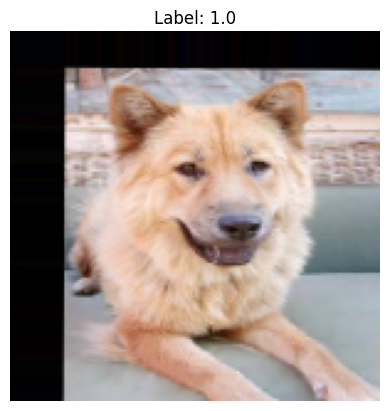

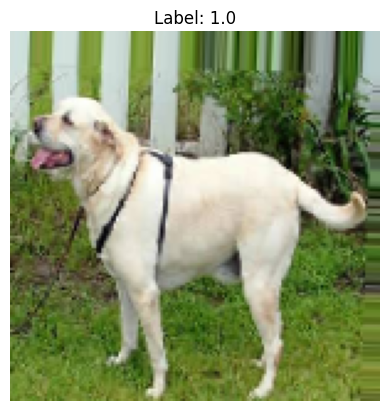

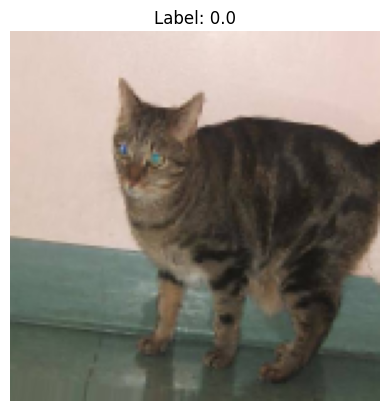

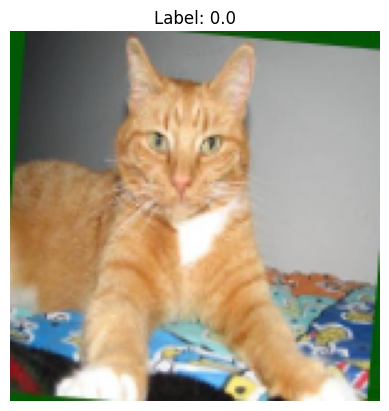

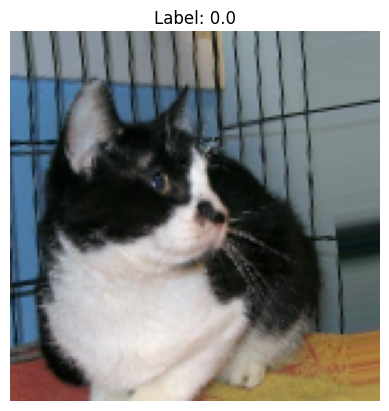

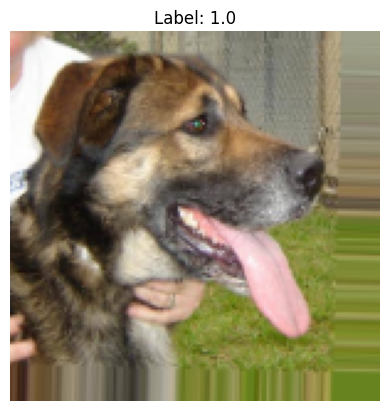

In [ ]:
# train argument images
x,y = next(train_generator)

for i in range(6):
  plt.imshow(x[i])
  plt.title(f'Label: {y[i]}')
  plt.axis('off')
  plt.show()

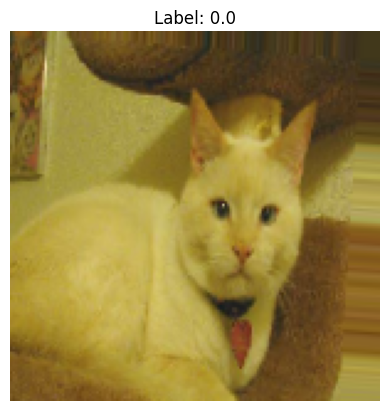

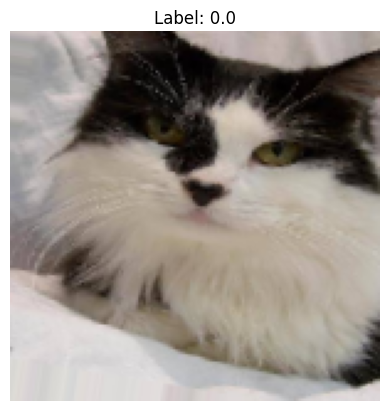

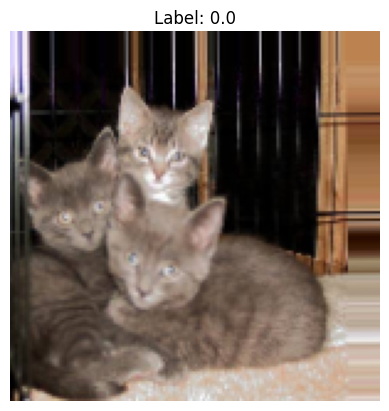

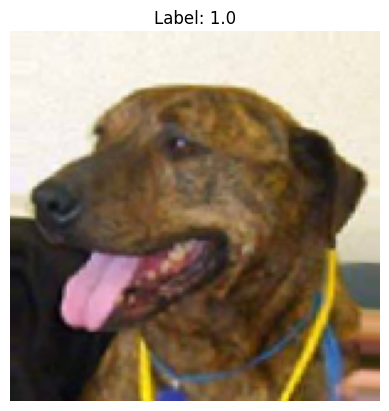

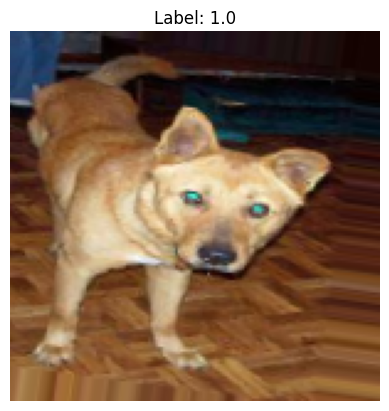

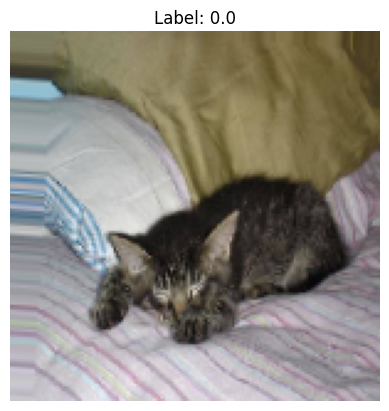

In [ ]:
# validation augmented images
x, y = next(val_generator)

for i in range(6):
    plt.imshow(x[i])
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
    plt.show()

In [ ]:
# images shape
x,y = next(train_generator)
print(x.shape)

(128, 150, 150, 3)


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [ ]:
# Comparison Original vs Resize
img_path = '/content/training_set/training_set/cats/cat.100.jpg'

img = image.load_img(img_path)
print('Original Size:',img.size)

img_resized = image.load_img(img_path,target_size=(150,150))
print('Resized Size:',img_resized.size)

Original Size: (403, 499)
Resized Size: (150, 150)


# Data Modeling With CNN

In a typical convulational Neural Networks (CNN) architecture.the input data goes through a series of layers organized in a hierarchical manner.Each Layer captures different levels of abstractions.and the information is progressively refined as it passes through the network.

In [ ]:
model=tf.keras.Sequential([
    #1st Layer CNN

    tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),input_shape=(150,150,3)),
    tf.keras.layers.MaxPool2D(),
    # Normalize the input of a layer in a neural networks
    tf.keras.layers.BatchNormalization(),
    # Dropout is a Regularization technique use to prevent overfitting
    tf.keras.layers.Dropout(0.2),

    #2nd Layer CNN

    tf.keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(),
    # Normalize the inputs of a layer in a neural network
    tf.keras.layers.BatchNormalization(),
    # Dropout is a regularization technique use to prevent overfitting
    tf.keras.layers.Dropout(0.2),

   #3rd Layer CNN

    tf.keras.layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(),
    # Normalize the inputs of a layer in a neural network
    tf.keras.layers.BatchNormalization(),
    # Dropout is a regularization technique use to prevent overfitting
    tf.keras.layers.Dropout(0.2),
    #flatten layer
    tf.keras.layers.Flatten(),
    #fully Connected Layer
    tf.keras.layers.Dense(512,activation='relu'),
    #Output layers
    tf.keras.layers.Dense(1,activation='sigmoid')
    ])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 74, 74, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,073 (72.61 MB)

 Trainable params: 19,034,625 (72.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_generator,epochs=25,validation_data=val_generator)

Epoch 1/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 442s 9s/step - accuracy: 0.5829 - loss: 3.6222 - val_accuracy: 0.4997 - val_loss: 2.2417
Epoch 2/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 431s 8s/step - accuracy: 0.6351 - loss: 1.1491 - val_accuracy: 0.5684 - val_loss: 0.7372
Epoch 3/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 437s 9s/step - accuracy: 0.6718 - loss: 0.6991 - val_accuracy: 0.4997 - val_loss: 1.5821
Epoch 4/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 422s 8s/step - accuracy: 0.7089 - loss: 0.5923 - val_accuracy: 0.4997 - val_loss: 2.4229
Epoch 5/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 429s 8s/step - accuracy: 0.7278 - loss: 0.5631 - val_accuracy: 0.5790 - val_loss: 0.9751
Epoch 6/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 421s 8s/step - accuracy: 0.7334 - loss: 0.5507 - val_accuracy: 0.5016 - val_loss: 1.9272
Epoch 7/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 423s 8s/step - accuracy: 0.7483 - loss: 0.5295 - val_accuracy: 0.5053 - val_loss: 1.5684
Epoch 8/25
51/51 ━━━━━━━━━━━━━━━━━━━━ 430s 8s/step - accuracy: 0.7616 - loss: 0.4990 - val_accuracy: 0.5703 - v

# Plotting MOdel Loss & Accuracy On Training & Validation Data

# 1.Loss

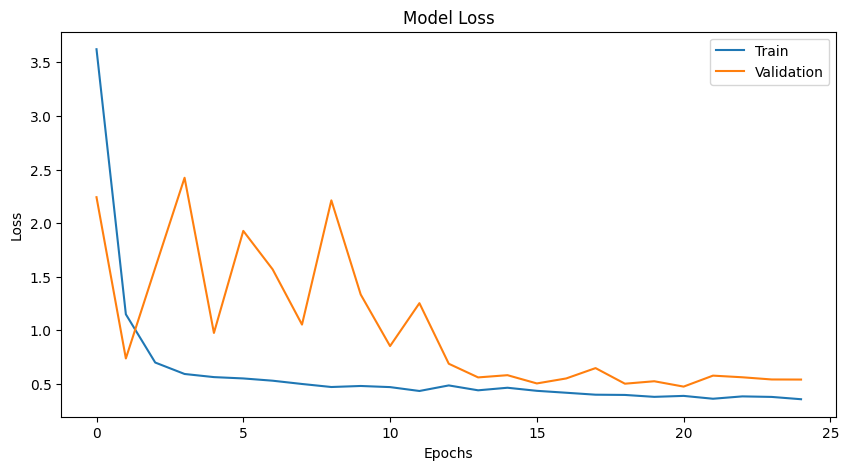

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Model Loss")
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

# 2.Accuracy

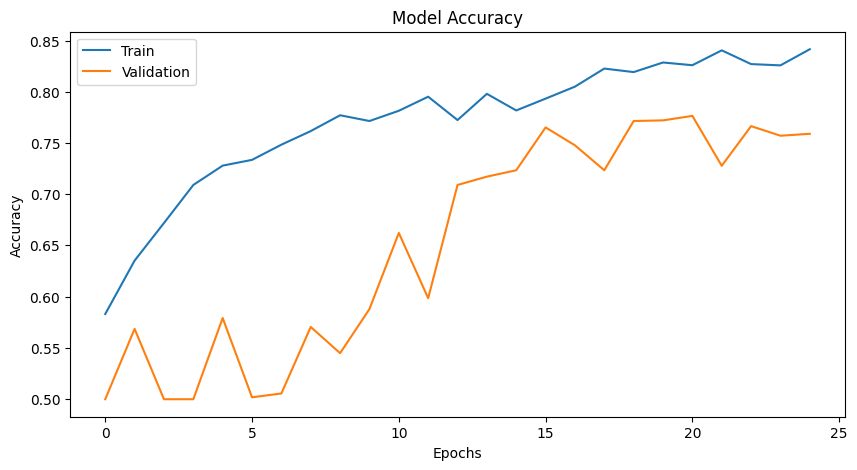

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Model Accuracy")
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

# Making Generator For Test Data

In [ ]:
# test generator
test_generator=datagen.flow_from_directory('/content/test_set/test_set',
  target_size=(150,150), #Resize the image to (150x150) pixels
  batch_size=128,  #Specifies the number of samples in each batch
  class_mode='binary') #Specifies the type of problem,which is binary classification in our case

Found 2023 images belonging to 2 classes.


# Evaluation Of Model Performance On Test Data

In [ ]:
loss,accuracy=model.evaluate(test_generator)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7647 - loss: 0.5759
Test Loss: 0.575851321220398
Test Accuracy: 0.7647058963775635


# Saving The Model in "h5" File

In [ ]:
model.save('cats_vs_dogs.h5')

# Loading Model To Do classification

In [ ]:
load_model=tf.keras.models.load_model('cats_vs_dogs.h5')

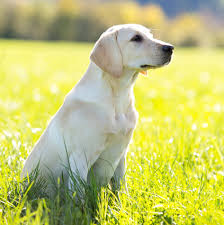

In [ ]:
img_url="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS5OwX8RwpUEDDnO2wtBPAG9IfIXx3Y_d2-MA&s"
img=Image.open(requests.get(img_url,stream=True).raw)
img

# Reshape the image

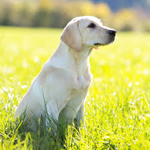

In [ ]:
img=img.resize((150,150))
img

# Converting IMage to Array

In [ ]:
img_array=image.img_to_array(img)

# Expanding Dimension on Array

In [ ]:
img=np.expand_dims(img_array,axis=0)

In [ ]:
img=img/255.0

# Result Of The Model

In [ ]:
prediction = model.predict(img)

threshold = 0.5

predicted_class = 'dog' if prediction > threshold else 'cat'

print(f"The predicted class is: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
The predicted class is: dog
